In [1]:
%reset -f


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
ROOT = Path("oulad_clustered_student_engagement")
DATA_RAW = ROOT / "data" / "raw"

studentInfo = pd.read_csv(DATA_RAW / "studentInfo.csv")
# studentVle = pd.read_csv(DATA_RAW / "studentVle.csv") --large data --load only when needed
assessments = pd.read_csv(DATA_RAW / "assessments.csv")
studentAssessment = pd.read_csv(DATA_RAW / "studentAssessment.csv")
courses = pd.read_csv(DATA_RAW / "courses.csv")
vle = pd.read_csv(DATA_RAW / "vle.csv")
studentReg = pd.read_csv(DATA_RAW / "studentRegistration.csv")

Data Cleaning: Removing the students who enrolled and unenrolled before the start of the course\. There are no students who unenrolled and enrolled again for the same course and the same presentation\.

In [8]:
# Identify students who unregistered before course start
neg_unreg = studentReg[
    studentReg["date_unregistration"].notna() &
    (studentReg["date_unregistration"] < 0)
]

neg_keys = neg_unreg[["id_student", "code_module", "code_presentation"]].drop_duplicates()


# Build keys to match exact student-course-presentation
studentInfo["key"] = (
    studentInfo["id_student"].astype(str) + "|" +
    studentInfo["code_module"].astype(str) + "|" +
    studentInfo["code_presentation"].astype(str)
)

neg_keys["key"] = (
    neg_keys["id_student"].astype(str) + "|" +
    neg_keys["code_module"].astype(str) + "|" +
    neg_keys["code_presentation"].astype(str)
)

# Remove only those rows
before = studentInfo.shape[0]
studentInfo = studentInfo[~studentInfo["key"].isin(neg_keys["key"])]
after = studentInfo.shape[0]

# Drop helper column
studentInfo = studentInfo.drop(columns=["key"])

print("Removed rows:", before - after)


Removed rows: 2678


studentInfo shape: (29915, 12)

Missing values (studentInfo):
imd_band                1054
code_module                0
id_student                 0
code_presentation          0
gender                     0
region                     0
highest_education          0
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

Final result counts:
final_result
Pass           12361
Withdrawn       7480
Fail            7050
Distinction     3024
Name: count, dtype: int64


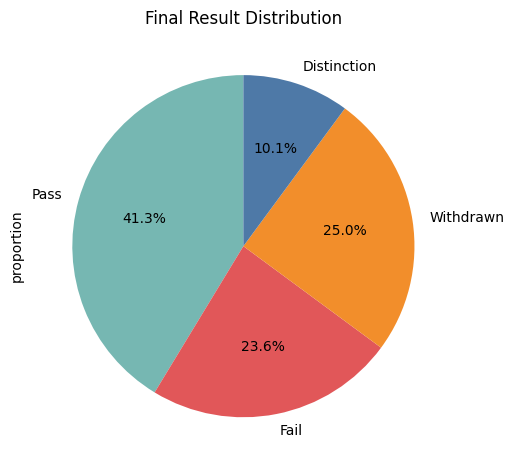

In [11]:
# -----------------------------
# 0) Minimal cleaning / standardization
# -----------------------------
si = studentInfo.copy()

# Normalize common categorical fields (safe + helpful for plots)
cat_cols = ["gender", "region", "highest_education", "imd_band", "age_band", "disability", "final_result"]
for c in cat_cols:
    if c in si.columns:
        si[c] = si[c].astype("string").str.strip()

# Optional: consistent ordering for final_result (if present)
final_order = ["Pass", "Fail", "Withdrawn", "Distinction"]
si["final_result"] = pd.Categorical(si["final_result"], categories=final_order, ordered=True)

# -----------------------------
# 1) Quick baseline summaries
# -----------------------------
print("studentInfo shape:", si.shape)
print("\nMissing values (studentInfo):")
print(si.isna().sum().sort_values(ascending=False))

print("\nFinal result counts:")
print(si["final_result"].value_counts(dropna=False))

# -----------------------------
# 2) Plot 1 — Outcome distribution (count) --make it to Pie Chart
# -----------------------------
outcome_counts = si["final_result"].value_counts(dropna=False).sort_index()
plt.figure()

colors = ["#76B7B2", "#E15759", "#F28E2B","#4E79A7"]
outcome_pct = (si["final_result"].value_counts(normalize=True, dropna=False).sort_index() * 100)
outcome_pct.plot(kind="pie",autopct="%.1f%%",startangle=90,colors=colors)

plt.title("Final Result Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

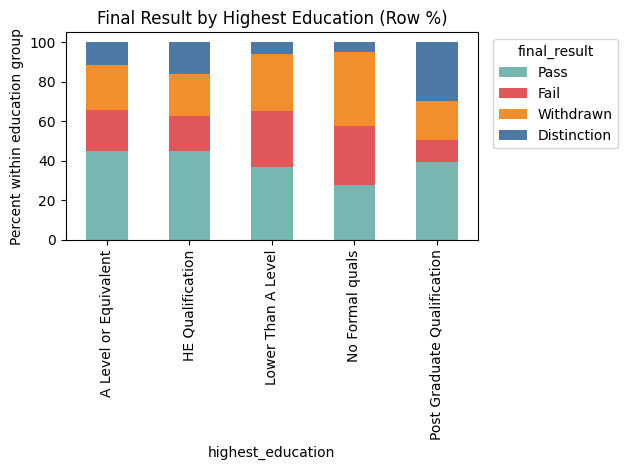

In [14]:
edu_outcome = pd.crosstab(si["highest_education"], si["final_result"], normalize="index") * 100
edu_outcome = edu_outcome.loc[edu_outcome.sum(axis=1).sort_values(ascending=False).index]  # sort by size/coverage

plt.figure()
edu_outcome.plot(kind="bar", stacked=True,
    color=colors)
plt.title("Final Result by Highest Education (Row %)")
plt.xlabel("highest_education")
plt.ylabel("Percent within education group")
plt.legend(title="final_result", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

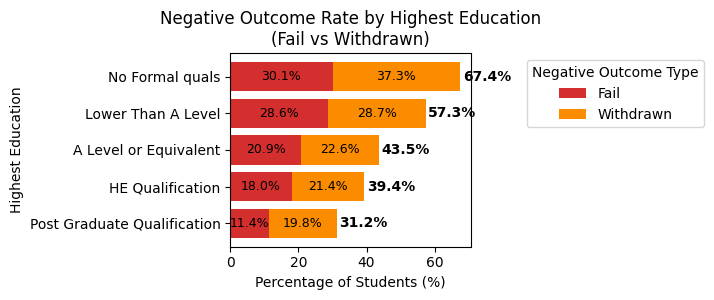

In [59]:
# Keep only Fail and Withdrawn
neg = si[si["final_result"].isin(["Fail", "Withdrawn"])]


# Percentage distribution of Fail vs Withdrawn within each education group
edu_outcome_split = (
    pd.crosstab(
        neg["highest_education"],
        neg["final_result"],
        normalize="index"
    ) * 100
)

si["is_negative_outcome"] = si["final_result"].isin(["Fail", "Withdrawn"])
risk_by_edu = ( si.groupby("highest_education")["is_negative_outcome"] .mean() .sort_values(ascending=False) .mul(100) .rename("neg_outcome_rate_%") )

# Overall negative outcome rate (already computed)
risk_total = risk_by_edu.loc[edu_outcome_split.index]

# Convert split % to absolute % of total population
edu_fail_pct = risk_total * (edu_outcome_split["Fail"] / 100)
edu_withdraw_pct = risk_total * (edu_outcome_split["Withdrawn"] / 100)

# Combine into one dataframe
stacked_risk = pd.DataFrame({
    "Fail": edu_fail_pct,
    "Withdrawn": edu_withdraw_pct
}).sort_values(by=["Fail", "Withdrawn"], ascending=False)

plt.figure(figsize=(8, 3.1))

plt.barh(
    stacked_risk.index,
    stacked_risk["Fail"],
    color="#D32F2F",
    label="Fail"
)

plt.barh(
    stacked_risk.index,
    stacked_risk["Withdrawn"],
    left=stacked_risk["Fail"],
    color="#FB8C00",
    label="Withdrawn"
)

plt.gca().invert_yaxis()

plt.title("Negative Outcome Rate by Highest Education\n(Fail vs Withdrawn)")
plt.xlabel("Percentage of Students (%)")
plt.ylabel("Highest Education")

# --- Annotate inner segments ---
for i, (fail, withdraw) in enumerate(
    zip(stacked_risk["Fail"], stacked_risk["Withdrawn"])
):
    if fail > 1:
        plt.text(fail / 2, i, f"{fail:.1f}%", va="center", ha="center",
                 color="black", fontsize=9)
    if withdraw > 1:
        plt.text(fail + withdraw / 2, i, f"{withdraw:.1f}%", va="center",
                 ha="center", color="black", fontsize=9)

# --- Annotate TOTAL negative outcome % at bar end ---
total_neg = stacked_risk.sum(axis=1)

for i, total in enumerate(total_neg):
    plt.text(
        total + 0.8,      # slight offset to the right of the bar
        i,
        f"{total:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

plt.legend(title="Negative Outcome Type", bbox_to_anchor=(1.2, 1), loc="upper left")
plt.tight_layout()
plt.show()


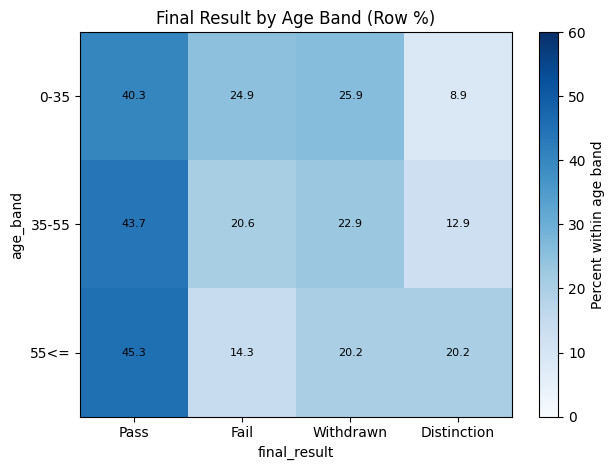

In [17]:
# -----------------------------
# 4) Plot 3 — Heatmap: age_band × final_result (row-normalized %)
# -----------------------------
age_outcome = pd.crosstab(si["age_band"], si["final_result"], normalize="index") * 100

plt.figure()
plt.imshow(age_outcome.values, aspect="auto", cmap="Blues", vmin=0, vmax=60)
plt.title("Final Result by Age Band (Row %)")
plt.xlabel("final_result")
plt.ylabel("age_band")
plt.xticks(range(age_outcome.shape[1]), age_outcome.columns, rotation=0)
plt.yticks(range(age_outcome.shape[0]), age_outcome.index)

# annotate cells
for i in range(age_outcome.shape[0]):
    for j in range(age_outcome.shape[1]):
        val = age_outcome.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.colorbar(label="Percent within age band")
plt.tight_layout()
plt.show()

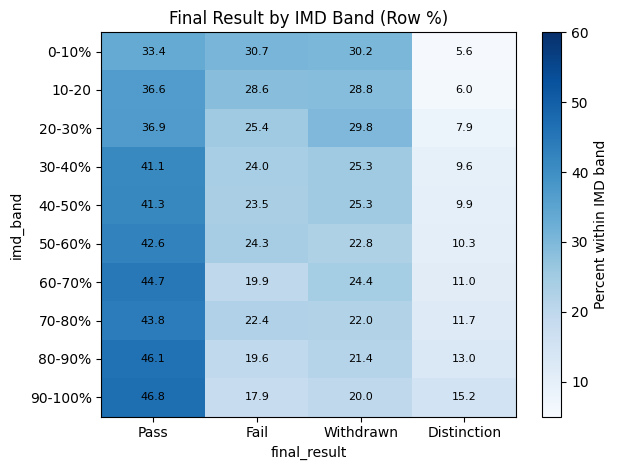

In [20]:
# -----------------------------
# 5) Plot 4 — Heatmap: IMD band × final_result (row-normalized %)
# -----------------------------
imd_outcome = pd.crosstab(si["imd_band"], si["final_result"], normalize="index") * 100
# Keep IMD in logical order if formatted like '0-10%', '10-20%', ...
imd_outcome = imd_outcome.reindex(sorted(imd_outcome.index, key=lambda x: (str(x).split("-")[0].replace("%","") if pd.notna(x) else "999")))

plt.figure()
plt.imshow(imd_outcome.values, aspect="auto", cmap="Blues", vmin=5, vmax=60)#YlGnBu
plt.title("Final Result by IMD Band (Row %)")
plt.xlabel("final_result")
plt.ylabel("imd_band")
plt.xticks(range(imd_outcome.shape[1]), imd_outcome.columns, rotation=0)
plt.yticks(range(imd_outcome.shape[0]), imd_outcome.index)

for i in range(imd_outcome.shape[0]):
    for j in range(imd_outcome.shape[1]):
        val = imd_outcome.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.colorbar(label="Percent within IMD band")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

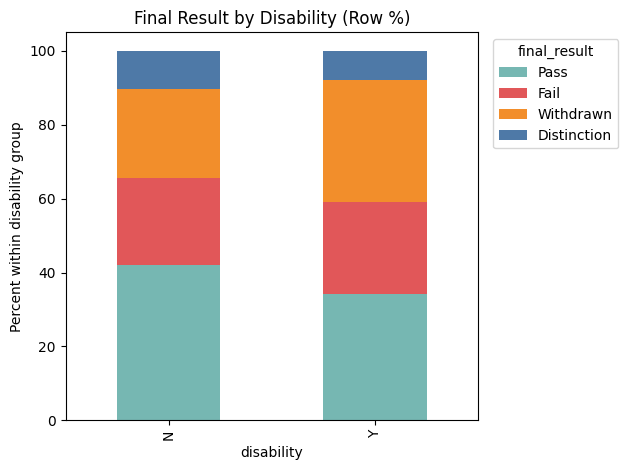

In [26]:
# -----------------------------
# 6) Plot 5 — Stacked bar: disability vs final_result (row %)
# -----------------------------
dis_outcome = pd.crosstab(si["disability"], si["final_result"], normalize="index") * 100

plt.figure()
dis_outcome.plot(kind="bar", stacked=True, color = colors)
plt.title("Final Result by Disability (Row %)")
plt.xlabel("disability")
plt.ylabel("Percent within disability group")
plt.legend(title="final_result", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [62]:
# 2️⃣ Early Assessment Behaviour (Weeks 0–4) — CODE ONLY
# Uses: studentAssessment, assessments, studentInfo
# Variable rename: ass -> asg

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Parameters
# -----------------------------
EARLY_DAYS_END = 28  # 0–4 weeks
VALID_OUTCOMES = ["Pass", "Fail", "Withdrawn", "Distinction"]

# -----------------------------
# 1) Build assessment master
# -----------------------------
asg = assessments.copy()
sa = studentAssessment.copy()
si = studentInfo[["id_student", "code_module", "code_presentation", "final_result"]].copy()

asg["date"] = pd.to_numeric(asg["date"], errors="coerce")
asg["weight"] = pd.to_numeric(asg["weight"], errors="coerce")
sa["score"] = pd.to_numeric(sa["score"], errors="coerce")
sa["date_submitted"] = pd.to_numeric(sa["date_submitted"], errors="coerce")

asg_early = asg[asg["date"].between(0, EARLY_DAYS_END)].copy()

# -----------------------------
# 2) Join studentAssessment ↔ assessments
# -----------------------------
sa_full = sa.merge(
    asg[["id_assessment", "code_module", "code_presentation", "date", "weight"]],
    on="id_assessment",
    how="left"
)

sa_early = sa_full[sa_full["date"].between(0, EARLY_DAYS_END)].copy()

sa_early = sa_early.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

sa_early = sa_early[sa_early["final_result"].isin(VALID_OUTCOMES)].copy()

# -----------------------------
# 3) Feature A: Early mean score
# -----------------------------
early_mean_score = (
    sa_early.groupby(["id_student", "code_module", "code_presentation"], as_index=False)
           .agg(early_mean_score=("score", "mean"))
)

early_mean_score = early_mean_score.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

early_mean_score = early_mean_score[
    early_mean_score["final_result"].isin(VALID_OUTCOMES)
]

# -----------------------------
# 4) Feature B: % missed early assessments
# -----------------------------
expected = si.merge(
    asg_early[["code_module", "code_presentation", "id_assessment"]],
    on=["code_module", "code_presentation"],
    how="inner"
)

submitted_early = sa_early[
    ["id_student", "code_module", "code_presentation", "id_assessment"]
].drop_duplicates()

expected = expected.merge(
    submitted_early.assign(submitted=1),
    on=["id_student", "code_module", "code_presentation", "id_assessment"],
    how="left"
)

expected["submitted"] = expected["submitted"].fillna(0)

missed_stats = (
    expected.groupby(["id_student", "code_module", "code_presentation"], as_index=False)
            .agg(
                n_early_assessments=("id_assessment", "nunique"),
                n_submitted_early=("submitted", "sum")
            )
)

missed_stats["n_missed_early"] = (
    missed_stats["n_early_assessments"] - missed_stats["n_submitted_early"]
)

missed_stats["pct_missed_early"] = np.where(
    missed_stats["n_early_assessments"] > 0,
    100 * missed_stats["n_missed_early"] / missed_stats["n_early_assessments"],
    np.nan
)

missed_stats = missed_stats.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

missed_stats = missed_stats[
    missed_stats["final_result"].isin(VALID_OUTCOMES)
]

# -----------------------------
# 5) Feature C: Time gap between submissions
# -----------------------------
sa_early_sorted = sa_early.sort_values(
    ["id_student", "code_module", "code_presentation", "date_submitted"]
)

sa_early_sorted["gap_days"] = (
    sa_early_sorted
    .groupby(["id_student", "code_module", "code_presentation"])["date_submitted"]
    .diff()
)

time_gap = (
    sa_early_sorted.groupby(
        ["id_student", "code_module", "code_presentation"], as_index=False
    )
    .agg(
        mean_gap_days=("gap_days", "mean"),
        median_gap_days=("gap_days", "median")
    )
)

time_gap = time_gap.merge(
    si,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

time_gap = time_gap[
    time_gap["final_result"].isin(VALID_OUTCOMES)
]

# -----------------------------
# 6) Feature D: Cumulative early score
# -----------------------------
sa_early["weighted_points"] = sa_early["score"] * (sa_early["weight"] / 100.0)

stu_day = (
    sa_early.groupby(
        ["id_student", "code_module", "code_presentation", "final_result", "date"],
        as_index=False
    )
    .agg(day_points=("weighted_points", "sum"))
)

stu_day = stu_day.sort_values(
    ["id_student", "code_module", "code_presentation", "date"]
)

stu_day["cum_points"] = (
    stu_day
    .groupby(["id_student", "code_module", "code_presentation"])["day_points"]
    .cumsum()
)

traj = (
    stu_day.groupby(["final_result", "date"], as_index=False)
           .agg(mean_cum_points=("cum_points", "mean"))
)


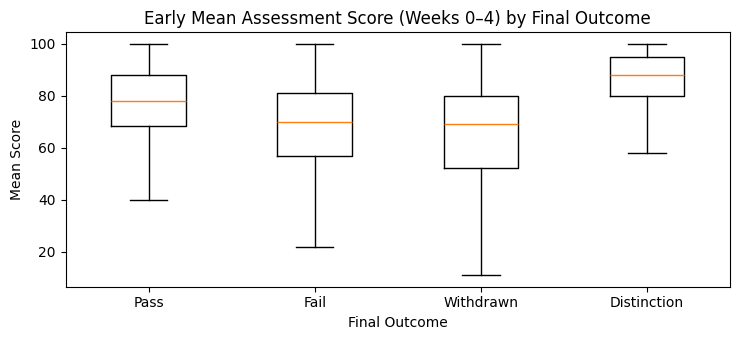

In [65]:
# Boxplot
data_for_box, labels = [], []
for out in VALID_OUTCOMES:
    vals = early_mean_score.loc[
        early_mean_score["final_result"] == out, "early_mean_score"
    ].dropna()
    if len(vals) > 0:
        data_for_box.append(vals)
        labels.append(out)

plt.figure(figsize=(7.5, 3.5))
plt.boxplot(data_for_box, labels=labels, showfliers=False)
plt.title("Early Mean Assessment Score (Weeks 0–4) by Final Outcome")
plt.xlabel("Final Outcome")
plt.ylabel("Mean Score")
plt.tight_layout()
plt.show()


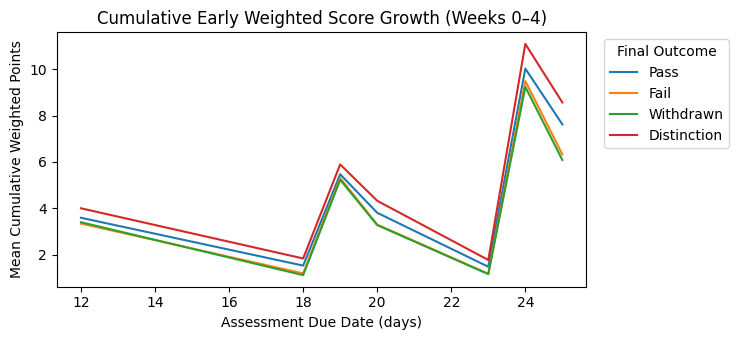

In [68]:
# Line plot
plt.figure(figsize=(7.5, 3.5))
for out in VALID_OUTCOMES:
    sub = traj[traj["final_result"] == out].sort_values("date")
    if len(sub) > 0:
        plt.plot(sub["date"], sub["mean_cum_points"], label=out)

plt.title("Cumulative Early Weighted Score Growth (Weeks 0–4)")
plt.xlabel("Assessment Due Date (days)")
plt.ylabel("Mean Cumulative Weighted Points")
plt.legend(title="Final Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


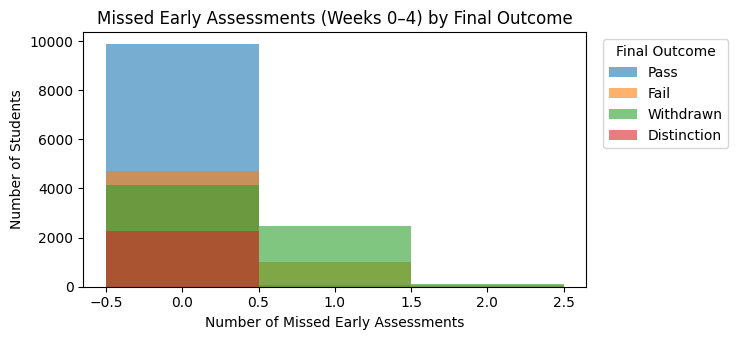

In [71]:
# Histogram
plt.figure(figsize=(7.5, 3.5))
bins = np.arange(0, missed_stats["n_missed_early"].max() + 2) - 0.5

for out in VALID_OUTCOMES:
    sub = missed_stats.loc[
        missed_stats["final_result"] == out, "n_missed_early"
    ].dropna()
    if len(sub) > 0:
        plt.hist(sub, bins=bins, alpha=0.6, label=out)

plt.title("Missed Early Assessments (Weeks 0–4) by Final Outcome")
plt.xlabel("Number of Missed Early Assessments")
plt.ylabel("Number of Students")
plt.legend(title="Final Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [56]:
def get_columns(dfs):
    return {f"df_{i}": df.columns.tolist() for i, df in enumerate(dfs)}



dfs = [studentInfo ,assessments ,studentAssessment , courses, vle, studentReg]
print(get_columns(dfs))

{'df_0': ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result'], 'df_1': ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight'], 'df_2': ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score'], 'df_3': ['code_module', 'code_presentation', 'module_presentation_length'], 'df_4': ['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to'], 'df_5': ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']}


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=915c48ff-4287-4f39-af89-419738985e00' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>